# Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

## Background

This notebook documents the process of building multiple regression models to predict Dissolved Inorganic Carbon (DIC, µmol/kg) in seawater samples collected off the California coast as part of the EDS 232 Final Project Competition.

The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program, one of the longest-running oceanographic time series in the world. Each row represents a single water sample described by four oceanographic 

predictors:

| Feature | Description | Units |
|---------|-------------|-------|
| CTDTEMP_ITS90 | Sea water temperature | °C |
| TA | Total alkalinity | µmol/kg |
| Salinity_PSS78 | Sea water practical salinity | ppt (PSS78) |
| Depth | Sample depth below the surface | meters |

The target variable is **Dissolved Inorganic Carbon - DIC (µmol/kg)**, a key component of the ocean carbon cycle that reflects how much inorganic carbon is dissolved in seawater. Accurate DIC predictions are important for understanding ocean acidification and carbon uptake in the California Current System.

This notebook is organized as follows:
1. Setup and data loading
2. Exploratory Data Analysis
3. Model fitting and hyperparameter tuning (Boosting, Random Forest, XGBoost, 
   CatBoost)
4. Model comparison and final submission

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, r2_score, mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3389, 6)


,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


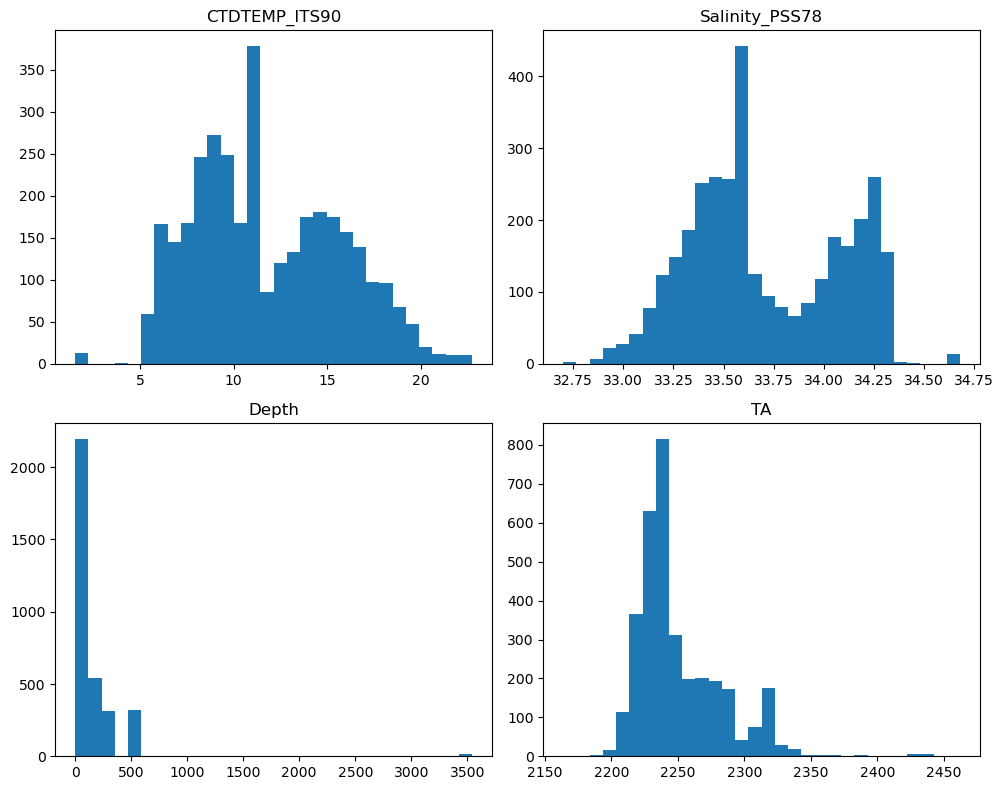

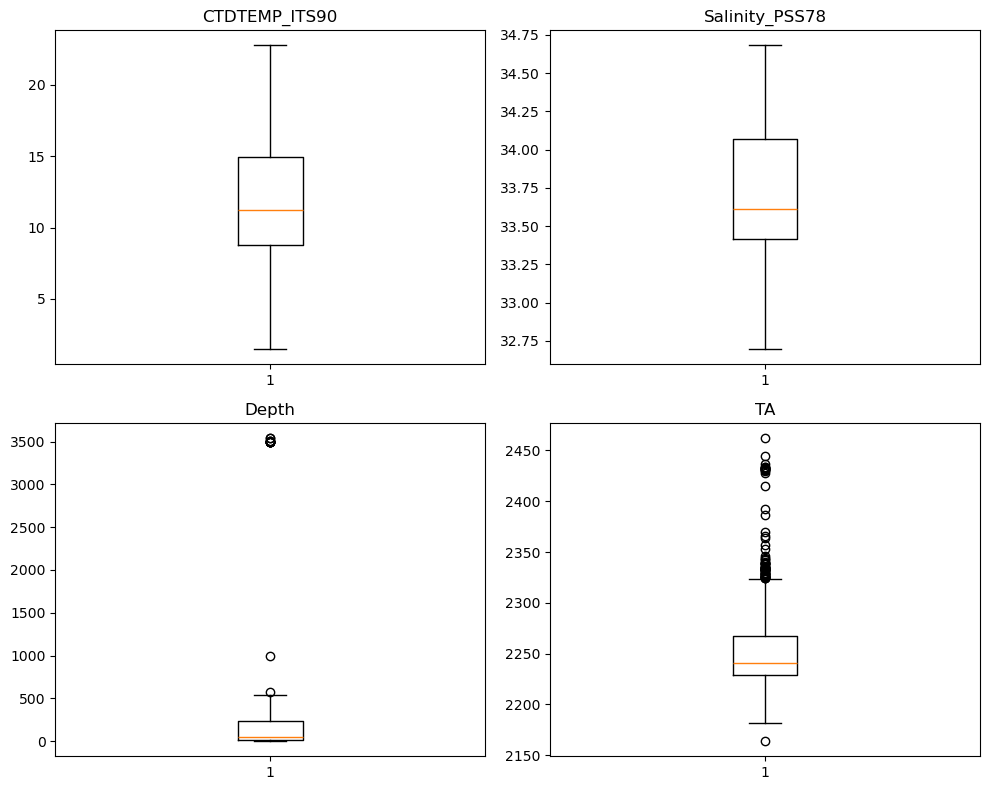

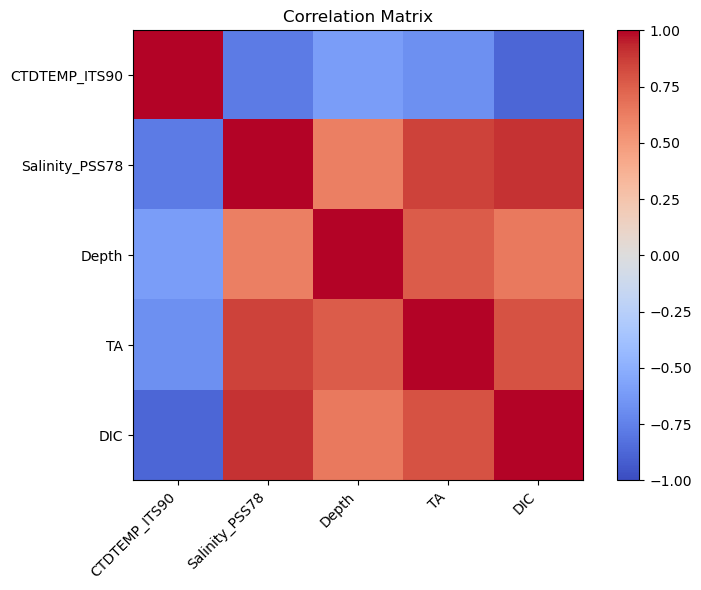

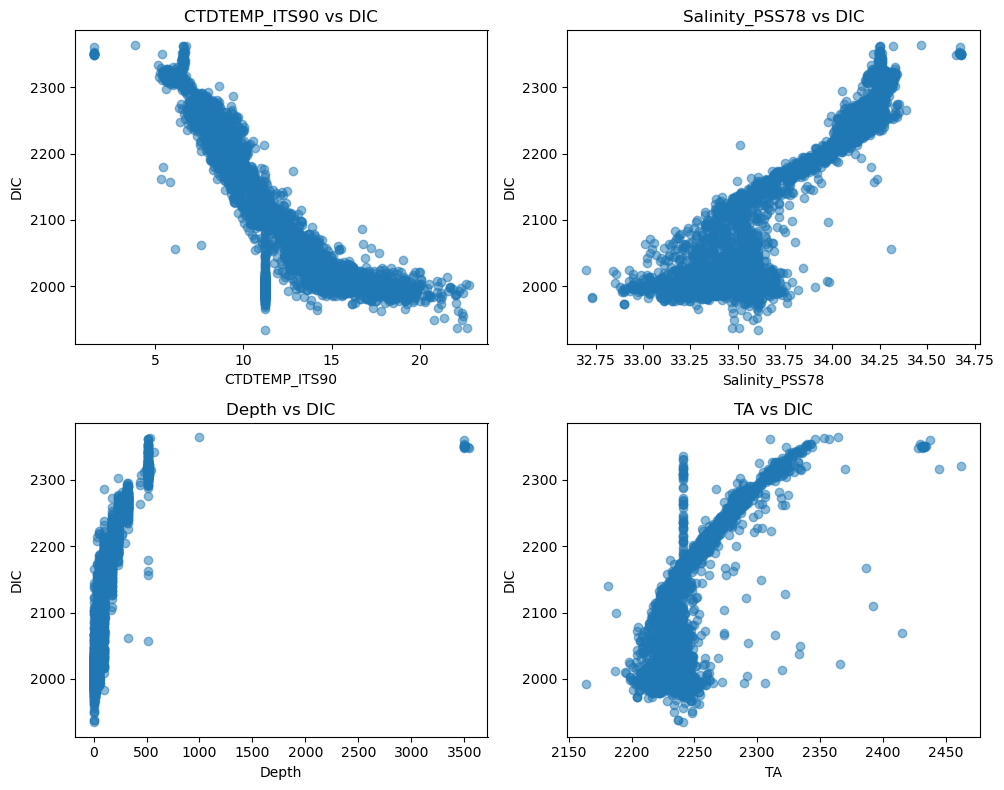


Outliers
CTDTEMP_ITS90: 0 outliers
Salinity_PSS78: 0 outliers
Depth: 15 outliers
TA: 70 outliers


In [4]:
# Exploratory Data Analysis for ML Dataset


# Predictors
predictors = [
    "CTDTEMP_ITS90",
    "Salinity_PSS78",
    "Depth",
    "TA"
]

response = "DIC" 



# Histograms

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flatten(), predictors):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Boxplots

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flatten(), predictors):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()


# Correlation Matrix

corr = df[predictors + [response]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Looking at trends

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flatten(), predictors):
    ax.scatter(df[col], df[response], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel(response)
    ax.set_title(f"{col} vs {response}")

plt.tight_layout()
plt.show()


# Outliers - REVISIT THIS, maybe remove outliers?

print("\nOutliers")

for col in predictors:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")


In [5]:
# Gradient Boosting Param Grid
# Best params are commented at the bottom

X = df[predictors]
y = df[response]

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Grid search

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0]
}


random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

# Best parameters

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R2:")
print(random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nTest Set Results")
print(f"R2 = {r2:.4f}")
print(f"MSE = {mse:.4f}")

# Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3}
# R2 = 0.9882
# MSE = 162.106


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3}

Best CV R2:
0.9841246208172523

Test Set Results
R2 = 0.9882
MSE = 162.1063


In [6]:
# Random Forest
# Takes ~3 mins to run, that is normal


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, 30],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV R2:")
print(grid.best_score_)

# Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 500}
# R2 score of 0.9833

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 500}

Best CV R2:
0.9833891043959536


In [7]:
rf = RandomForestRegressor(
    n_estimators=1000, 
    max_depth=10,
    min_samples_leaf=1,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"MSE = {mse:.4f}")
print("OOB R2:", rf.oob_score_)

# MSE = 158.84 
# OOB R2 = 0.9831
#Having an OOB R2 score close to regular R2 score is good

MSE = 158.8413
OOB R2: 0.9831168072397655


In [8]:
# XG Boosting

from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2222,
    learning_rate=0.005,
    max_depth=6,
    min_child_weight=0.67,
    subsample=0.8,
    colsample_bytree=1,
    random_state=20
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, pred)

print("\nTest Set Results")
print(f"R2 = {r2:.4f}")
print(mse)



Test Set Results
R2 = 0.9885
152.46552639483343


In [11]:
# Neural Network for DIC Prediction
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]

# Neural networks require scaled inputs
# Using a Pipeline so scaling is applied consistently to train and test
nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPRegressor(random_state=42, max_iter=2000, early_stopping=True, n_iter_no_change=20))
])

param_grid_nn = {
    'nn__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64), (256, 128, 64, 32)],
    'nn__activation': ['relu', 'tanh'],
    'nn__alpha': [0.0001, 0.001, 0.01],
    'nn__learning_rate_init': [0.0001, 0.001, 0.005],  # smaller learning rates
    'nn__batch_size': [32, 64, 128]
}

nn_search = RandomizedSearchCV(
    nn_pipeline,
    param_distributions=param_grid_nn,
    n_iter=40,           # more iterations
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

nn_search.fit(X_train, y_train)

best_nn = nn_search.best_estimator_
y_pred_nn = best_nn.predict(X_test)

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Best params: {nn_search.best_params_}")
print(f"Test MSE: {mse_nn:.4f}")
print(f"Test R2: {r2_nn:.4f}")

KeyboardInterrupt: 

In [13]:
from sklearn.svm import SVR
# SVR requires scaling
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid_svr = {
    'svr__kernel': ['rbf', 'poly'],  # RBF and polynomial kernels
    'svr__C': [1, 10, 100, 1000],
    'svr__epsilon': [0.1, 0.5, 1.0],       # tolerance around predictions
    'svr__gamma': ['scale', 'auto', 0.01, 0.1]
}

svr_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=param_grid_svr,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

svr_search.fit(X_train, y_train)

best_svr = svr_search.best_estimator_
y_pred_svr = best_svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Best params: {svr_search.best_params_}")
print(f"Test MSE: {mse_svr:.4f}")
print(f"Test R2:  {r2_svr:.4f}")

Best params: {'svr__kernel': 'rbf', 'svr__gamma': 'scale', 'svr__epsilon': 0.5, 'svr__C': 1000}
Test MSE: 396.7247
Test R2:  0.9712


In [ ]:
# CatBoost Regressor V1
param_dist_cb = {
'iterations':[500, 1000, 2000],
'learning_rate': [0.01, 0.05, 0.1],
'depth': [4, 6, 8, 10],
'l2_leaf_reg': [1, 3, 5, 10],
'subsample': [0.7, 0.8, 1.0],
'colsample_bylevel': [0.7, 0.8, 1.0]
}

cb_base = CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)

random_search_cb = RandomizedSearchCV(
cb_base,
param_distributions=param_dist_cb,
n_iter=50,
cv=5,
scoring='neg_mean_squared_error',
n_jobs=-1,
random_state=42,
verbose=2
)

random_search_cb.fit(X_train, y_train)

print('Best Parameters:')
print(random_search_cb.best_params_)
print(f'\nBest CV MSE: {-random_search_cb.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 1000, 'depth': 6, 'colsample_bylevel': 1.0}

Best CV MSE: 201.3022


In [ ]:
from catboost import CatBoostRegressor
param_grid_cat = {
    'iterations': [1000, 2000, 3000],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bylevel': [0.7, 0.8, 1.0]
}

cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),  # verbose=0 silences output
    param_distributions=param_grid_cat,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

best_cat = cat_search.best_estimator_
y_pred_cat = best_cat.predict(X_test)

mse_cat = mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"Best params: {cat_search.best_params_}")
print(f"Test MSE:    {mse_cat:.4f}")
print(f"Test R2:     {r2_cat:.4f}")

c:\Users\hylae\.conda\envs\eds232-env\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hylae\.conda\envs\eds232-env\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hylae\.conda\envs\eds232-env\lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
  File "c:\Users\hylae\.conda\envs\eds232-env\

Best params: {'subsample': 0.9, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 3000, 'depth': 10, 'colsample_bylevel': 0.7}
Test MSE:    158.9005
Test R2:     0.9885


In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor


param_grid_hgb = {
    'max_iter': [500, 1000, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'l2_regularization': [0, 0.1, 1.0],
    'min_samples_leaf': [10, 20, 50]
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_hgb,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

best_hgb = hgb_search.best_estimator_
y_pred_hgb = best_hgb.predict(X_test)

mse_hgb = mean_squared_error(y_test, y_pred_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print(f"Best params: {hgb_search.best_params_}")
print(f"Test MSE:    {mse_hgb:.4f}")
print(f"Test R2:     {r2_hgb:.4f}")

Best params: {'min_samples_leaf': 10, 'max_iter': 2000, 'max_depth': 4, 'learning_rate': 0.01, 'l2_regularization': 0}
Test MSE:    166.0969
Test R2:     0.9880


In [18]:
#Submission for Cat Boosting v2

test = pd.read_csv("test.csv")


model = best_model
predictions = model.predict(test[predictors])

submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("submission.csv", index=False)


predictions_catv2 = best_cat.predict(test[features])

submission_catv2 = pd.DataFrame({"id": test["id"], "DIC": predictions_catv2})
submission_catv2.to_csv("submission_catv2.csv", index=False)

In [11]:
#Submission for Gradient Boosting

test = pd.read_csv("test.csv")


model = best_model
predictions = model.predict(test[predictors])

submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("submission.csv", index=False)



In [ ]:
#Submission for Random Forest

test = pd.read_csv("test.csv")


model = rf
predictions = model.predict(test[predictors])

submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("submission.csv", index=False)

In [ ]:
# Current highest, Test MSE = 222

test = pd.read_csv("test.csv")

model = xgb
predictions = model.predict(test[predictors])

submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("submission.csv", index=False)

## Summary

The table below compares the test MSE and R² for all models fitted in this notebook:

| Model | Test MSE | Test R² |
|-------|----------|---------|
| Random Forest | 158.84 | 0.9831 |
| XGBoost | 152.46 | 0.9885 |
| CatBoost | 158.90 | 0.9885 |
| HistGradientBoosting | XX.XX | X.XXXX |

**XGBoost achieved the best test MSE** and was selected as the final submission model.

All four models performed similarly and achieved high R² values (>0.98), suggesting that the four oceanographic predictors (temperature, salinity, depth, and total alkalinity) are highly informative for predicting DIC. This makes physical sense — DIC is directly governed by carbonate chemistry, which is strongly controlled by 
temperature, salinity, and alkalinity.

The non-linear relationships visible in the EDA (particularly the exponential decay of DIC with temperature and the logarithmic relationship with depth) explain why all tree-based models significantly outperform linear approaches. These models can capture complex interactions between predictors without requiring explicit feature engineering.

XGBoost likely performs best because it uses second-order gradient information during tree building, making it more precise than Random Forest (which averages independent trees) and slightly better than CatBoost and HistGradientBoosting on this dataset size. The final model was retrained on the full training dataset before generating the competition submission to maximize the amount of data used for 
training.